In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

In [9]:
noteevents = pd.read_csv(
    "../datasets/NOTEEVENTS_sorted.csv",
    usecols=[
        "SUBJECT_ID",
        "HADM_ID",
        "CATEGORY",
        "CHARTDATE",
        "TEXT"
    ],
    low_memory=False
)

admissions = pd.read_csv(
    "../datasets/ADMISSIONS_sorted.csv",
    usecols=[
        "SUBJECT_ID",
        "HADM_ID",
        "ADMISSION_TYPE",
        "DIAGNOSIS",
        "HOSPITAL_EXPIRE_FLAG"
    ]
)

diagnoses = pd.read_csv(
    "../datasets/DIAGNOSES_ICD_sorted.csv",
    usecols=[
        "SUBJECT_ID",
        "HADM_ID",
        "ICD9_CODE",
        "SEQ_NUM"
    ]
)

print("NOTEEVENTS shape:", noteevents.shape)
print("ADMISSIONS shape:", admissions.shape)
print("DIAGNOSES shape:", diagnoses.shape)

NOTEEVENTS shape: (482770, 5)
ADMISSIONS shape: (12911, 5)
DIAGNOSES shape: (118300, 4)


In [10]:
print("\n=== Missing Values ===\n")

for name, df in {
    "NOTEEVENTS": noteevents,
    "ADMISSIONS": admissions,
    "DIAGNOSES": diagnoses
}.items():

    print(f"\n{name}")
    print(df.isnull().sum())


=== Missing Values ===


NOTEEVENTS
SUBJECT_ID        0
HADM_ID       48303
CHARTDATE         0
CATEGORY          0
TEXT              0
dtype: int64

ADMISSIONS
SUBJECT_ID              0
HADM_ID                 0
ADMISSION_TYPE          0
DIAGNOSIS               8
HOSPITAL_EXPIRE_FLAG    0
dtype: int64

DIAGNOSES
SUBJECT_ID     0
HADM_ID        0
SEQ_NUM       13
ICD9_CODE     13
dtype: int64


In [11]:
print("\n=== Note Categories ===\n")

category_counts = (
    noteevents["CATEGORY"]
    .value_counts()
)

print(category_counts.head(20))


=== Note Categories ===

CATEGORY
Nursing/other        291802
Radiology            104995
ECG                   43631
Discharge summary     13063
Nursing               10268
Echo                   9174
Physician              7407
Respiratory            1290
General                 440
Nutrition               383
Social Work             126
Rehab Services          119
Case Management          67
Pharmacy                  3
Consult                   2
Name: count, dtype: int64


In [12]:
notes = (
    noteevents[
        noteevents["CATEGORY"] == "Discharge summary"
    ]
    .copy()
)

print("\n=== Discharge Summaries ===")
print(f"Rows: {len(notes):,}")
print(f"Unique patients: {notes['SUBJECT_ID'].nunique():,}")
print(f"Unique admissions: {notes['HADM_ID'].nunique():,}")



=== Discharge Summaries ===
Rows: 13,063
Unique patients: 8,367
Unique admissions: 11,061


In [13]:
notes["CHARTDATE"] = pd.to_datetime(
    notes["CHARTDATE"],
    errors="coerce"
)


notes = (
    notes
    .sort_values("CHARTDATE")
    .drop_duplicates(
        subset="HADM_ID",
        keep="last"
    )
    .reset_index(drop=True)
)

print("\n=== After Deduplication ===")
print(f"Rows: {len(notes):,}")


=== After Deduplication ===
Rows: 11,061


In [14]:
notes = notes.merge(
    admissions,
    on=["SUBJECT_ID", "HADM_ID"],
    how="left"
)

print("\nMerged notes shape:", notes.shape)


Merged notes shape: (11061, 8)


In [15]:
notes["char_length"] = notes["TEXT"].astype(str).apply(len)

notes["word_count"] = (
    notes["TEXT"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print("\n=== Note Length Statistics ===\n")

print(
    notes[
        ["char_length", "word_count"]
    ].describe()
)



=== Note Length Statistics ===

        char_length    word_count
count  11061.000000  11061.000000
mean    8254.762228   1236.122322
std     4771.208878    721.379653
min      215.000000     21.000000
25%     5042.000000    747.000000
50%     7337.000000   1099.000000
75%    10599.000000   1592.000000
max    45149.000000   6602.000000


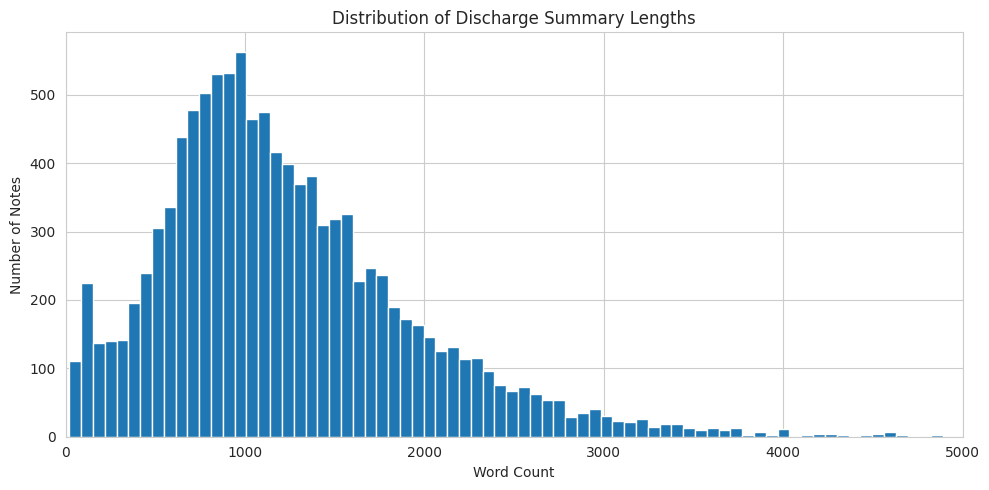

In [17]:
plt.figure(figsize=(10, 5))

plt.hist(
    notes["word_count"],
    bins=100
)

plt.xlim(0, 5000)

plt.xlabel("Word Count")
plt.ylabel("Number of Notes")
plt.title("Distribution of Discharge Summary Lengths")

plt.tight_layout()

plt.savefig(
    "../outputs/note_length_distribution.png",
    dpi=150
)

plt.show()